<a href="https://colab.research.google.com/github/olucasaguiar/projeto-simulacao-opiniao-publica/blob/feature%2Fimproving-sv-model/ml_simulation/simulacao_opiniao_publica_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from xgboost import XGBClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from scipy.spatial.distance import jensenshannon

# 1. Selecionando as features
fx_id_order = [
    "16 E 17",
    "18 A 24",
    "25 A 34",
    "35 A 44",
    "45 A 54",
    "55 A 64",
    "65 E MAIS",
]
p4_order = [
    "Não sabe/ Não respondeu",
    "Nenhuma vontade",
    "Alguma vontade",
    "Muita vontade",
]
renda_order = [
    "NÃO RESPONDEU",
    "NÃO TEM RENDIMENTO PESSOAL",
    "ATÉ 1",
    "MAIS DE 1 A 2",
    "MAIS DE 2 A 5",
    "MAIS DE 5 A 10",
    "MAIS DE 10 A 20",
    "MAIS DE 20",
]

# { features ordinais: ordem das categorias }
ordinal_features = {
    "FX_ID": fx_id_order,
    "P4": p4_order,
    "REND1": renda_order,
    "REND2": renda_order,
}

# features de categoria que não possuí uma ordem específica
nominal_features = [
    "SEXO",
    "ESCOLARIDADE",
    "P1A",
    "P1B",
    "P1C",
    "RACA",
    "RELIGIAO",
    "REGIAO",
    "COND",
]

# Targets:
# P2_1 => "Qual dessas propostas você acha que deveria ser prioridade de um(a) político(a)?"
# P3_1 => "Quais dessas opções você acredita que poderiam contribuir no combate à divulgação de fake news?" ⁠
s_targets = ["P2_1", "P3_1"]

# 2. Carregamento dos Dados
train_data_url = "https://raw.githubusercontent.com/olucasaguiar/projeto-simulacao-opiniao-publica/main/ml_simulation/data/df_train.csv"
df_train = pd.read_csv(train_data_url)
test_data_url = "https://raw.githubusercontent.com/olucasaguiar/projeto-simulacao-opiniao-publica/main/ml_simulation/data/df_test.csv"
df_test = pd.read_csv(test_data_url)

# Separando as features (X) e os targets (y) para os conjuntos de treino e teste.
X_train, X_test = (
    df_train[list(ordinal_features.keys()) + nominal_features],
    df_test[list(ordinal_features.keys()) + nominal_features],
)
y_train, y_test = df_train[s_targets], df_test[s_targets]

In [15]:
def simplify_nominal_features(df, cols, threshold=0.05):
    """
    Transforma os dados infrequentes (< threshold) de features nominais em um agrupamento de 'Outros'.
    Categorias nominais que serão aplicadas o OneHotEncoder na pipeline,
    produz matriz esparça ampla devido a cardinalidade. Diminuindo o número de categorias é uma maneira
    de mitigar o problema e, potencialmente, melhora o desempenho do modelo de classificação.
    """
    df_copy = df.copy()
    for col in cols:
        # Calcula a contagem de valores normalizada para a coluna atual.
        counts = df_copy[col].value_counts(normalize=True)
        # Identifica as categorias cuja frequência é menor que o limiar.
        low_freq = counts[counts < threshold].index
        # Substitui essas categorias de baixa frequência por 'Outros'.
        df_copy[col] = df_copy[col].apply(lambda x: "Outros" if x in low_freq else x)
    return df_copy


def simplify_targets(df, cols, threshold=0.03):
    """
    Transforma os dados infrequentes (< threshold) de categorias infrequentes no
    conjunto de resposta em uma categoria "Outros/Diversos".
    O treinamento de um conjunto cujo o valor do target possui inúmeras categorias
    pode ser um desafio para a acurácia caso não possua uma quantidade de elementos
    o suficiente no conjunto de teste para cada uma das respostas. Nesse caso,
    os dados infrequentes são agrupados para evitar o treinamento de dados com quantidades
    baixas.
    """
    df_copy = df.copy()
    for col in cols:
        # Realiza a contagem de valores únicos e normaliza em Serie Linear
        counts = df_copy[col].value_counts(normalize=True)
        # Identifica as categorias cuja frequência atinge ou excede o limiar.
        to_keep = counts[counts >= threshold].index
        # Substitui as categorias de baixa frequência por 'Outros/Diversos'.
        df_copy[col] = df_copy[col].apply(
            lambda x: x if x in to_keep else "Outros/Diversos"
        )
    return df_copy


# Aplica a função de simplificação às features nominais
X_train_sim = simplify_nominal_features(X_train, nominal_features)
X_test_sim = simplify_nominal_features(X_test, nominal_features)

# Para os targets, aplicamos a simplificação de targets e codificação com LabelEncoder
# LabelEncoder converte rótulos categóricos em rótulos numéricos (0, 1, 2, ...)
target_encoders = [LabelEncoder() for _ in s_targets]

# Aplica a função de simplificação e codificação dos targets do conjunto de treinamento
y_train_sim = simplify_targets(y_train, s_targets)  # treino COM simplificação de categorias
# y_train_sim = y_train  # treino SEM simplificação de categorias
y_train_enc = np.stack(
    [
        target_encoders[i].fit_transform(y_train_sim[col])
        for i, col in enumerate(s_targets)
    ],
    axis=1,
)

# Aplica a função de simplificação e codificação dos targets do conjunto de teste
y_test_sim = simplify_targets(y_test, s_targets)  # teste COM simplificação de categorias
# y_test_sim = y_test  # teste SEM simplificação de categorias
y_test_enc = np.stack(
    [target_encoders[i].transform(y_test_sim[col]) for i, col in enumerate(s_targets)],
    axis=1,
)

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer


def multioutput_f1_weighted(y_true, y_pred):
    """
    Como estamos utilizando um modelo de classificação com múltiplas saídas (multioutput),
    precisamos customizar a função de avaliação para levar em conta as múltiplas saídas.
    A função calcula o F1-Score ponderado para cada saída (target) individualmente
    e então retorna a média desses F1-Scores.
    """
    scores = []
    for i in range(y_true.shape[1]):
        score = f1_score(y_true[:, i], y_pred[:, i], average="weighted")
        scores.append(score)
    return np.mean(scores)

rng = np.random.RandomState(42)

# Cria um objeto scorer a partir da função customizada para ser compatível com scikit-learn.
custom_f1_scorer = make_scorer(multioutput_f1_weighted)

# Pipeline de pré-processamento das features
# Para features separadas como "ordinais" aplicamos o OrdinalEncoder com um "peso" pré-determinado
# > Adicionamos de forma explícita as categorias para evitar que o conjunto de teste possuam valores
# > não vistos durante o treinamento
# Para features separadas como "nominais" aplicamos o OneHotEncoder com a estratégia drop_first
# afim de reduzir problemas de colinearidade que costumam penalizar modelos de classificação linear
preprocessor = ColumnTransformer(
    transformers=[
        # 'ord': Aplica OrdinalEncoder para features ordinais.
        (
            "ord",
            OrdinalEncoder(
                categories=[ordinal_features[c] for c in ordinal_features.keys()],
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            list(ordinal_features.keys()),
        ),
        # 'nom': Aplica OneHotEncoder para features nominais.
        (
            "nom",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='first'),
            nominal_features,
        ),
    ]
)

# Modelo base: XGBClassifier é um algoritmo de boosting baseado em árvores.
# Alteramos o modelo RandomForestClassifier utilizado anteriormente para
# avaliação das métricas com um modelo reconhecido pela sua alta eficiênca
# em resolver problemas de classificação multi-classes e capacidade em evitar
# problemas de sobreajuste (overfit)
xgb = XGBClassifier(random_state=rng, tree_method="hist")

# Utilizamos o ClassifierChain para lidar com as duas saídas esperadas pela simulação
# Primeiro o modelo trata as saídas para o target P2_1 e, em seguida, realimenta o modelo
# para classificar o target P3_1
chain = ClassifierChain(xgb, order=[0, 1])

# Estamos utilizando a técnica de busca dos melhoraes parâmetros para o modelo
# Utilizamos o GridSearchCV para identificar os hiper-parametros:
# n_estimators, learning_rate e max_depth
# O `if` abaixo serve para compatibilidade entre versões diferentes da biblioteca `sklearn`
# Foi observado uma versão diferente no ambiente local e Google Colaboratory
if "estimator" in chain.get_params():
    param_grid = {
        "estimator__n_estimators": [100, 250],  # Número de árvores no modelo XGBoost
        "estimator__learning_rate": [0.01, 0.05, 0.1],  # Taxa de aprendizado
        "estimator__max_depth": [3, 5, 7],  # Profundidade máxima de cada árvore
    }
else:
    param_grid = {
        "base_estimator__n_estimators": [100, 250],
        "base_estimator__learning_rate": [0.01, 0.05, 0.1],
        "base_estimator__max_depth": [3, 5, 7],
    }

# Parâmetros utilizados para o GridSearchCV
# 'cv=5' usa validação cruzada com 5 folds.
#        Garante que cada conjunto é utilizado para treino e teste pelo menos uma vez
# 'scoring=custom_f1_scorer' usa nosso avaliador customizado.
# 'n_jobs=-1' utiliza todos os núcleos da CPU para paralelizar a busca.
grid_search = GridSearchCV(chain, param_grid, cv=5, scoring=custom_f1_scorer, n_jobs=-1)

# Utilizamos o Pipeline para garantir consistência na utilização da cadeia
# de treino/teste em cada cenário avaliado
# Primeiro: Aplica as transformações das features com o Pipeline especial
#           ColumnTransformer definido anteriormente
# Segundo: Aplica a função fit/predict do classificador XGB (com GridSearchCV para fit)
train_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", grid_search),
    ],
    verbose=True,
)

# Realiza o treinamento do modelo
train_pipeline.fit(X_train_sim, y_train_enc)
print("Treinamento do modelo com conjunto de treinamento realizado com sucesso.")

print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor F1-Score (CV): {grid_search.best_score_:.4f}")

# Utiliza o melhor modelo gerado com o GridSearchCV para predição dos valores do conjunto de teste
y_pred = train_pipeline.predict(X_test_sim)
print("Classificação do conjunto de testes finalizado com sucesso.")

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ........ (step 2 of 2) Processing classifier, total= 1.5min
Treinamento do modelo com conjunto de treinamento realizado com sucesso.
Melhores parâmetros: {'base_estimator__learning_rate': 0.1, 'base_estimator__max_depth': 3, 'base_estimator__n_estimators': 250}
Melhor F1-Score (CV): 0.2111
Classificação do conjunto de testes finalizado com sucesso.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


** Relatório de Métricas (F1-Score) **

Target: P2_1
                                                                               precision    recall  f1-score   support

Combater o preconceito (racismo, homofobia, diferença de classe social, etc.)       0.17      0.10      0.12        31
                                             Incentivar a geração de empregos       0.26      0.19      0.22        37
                                             Melhorar a qualidade da educação       0.18      0.14      0.16        21
                                                Melhorar a qualidade da saúde       0.21      0.43      0.28        35
                                                              Outros/Diversos       0.00      0.00      0.00        16
                                       Preservar os valores ligados à família       0.00      0.00      0.00         9
                                                          Reduzir a violência       0.17      0.16      0.16     

/tmp/ipykernel_15959/487001949.py:58: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


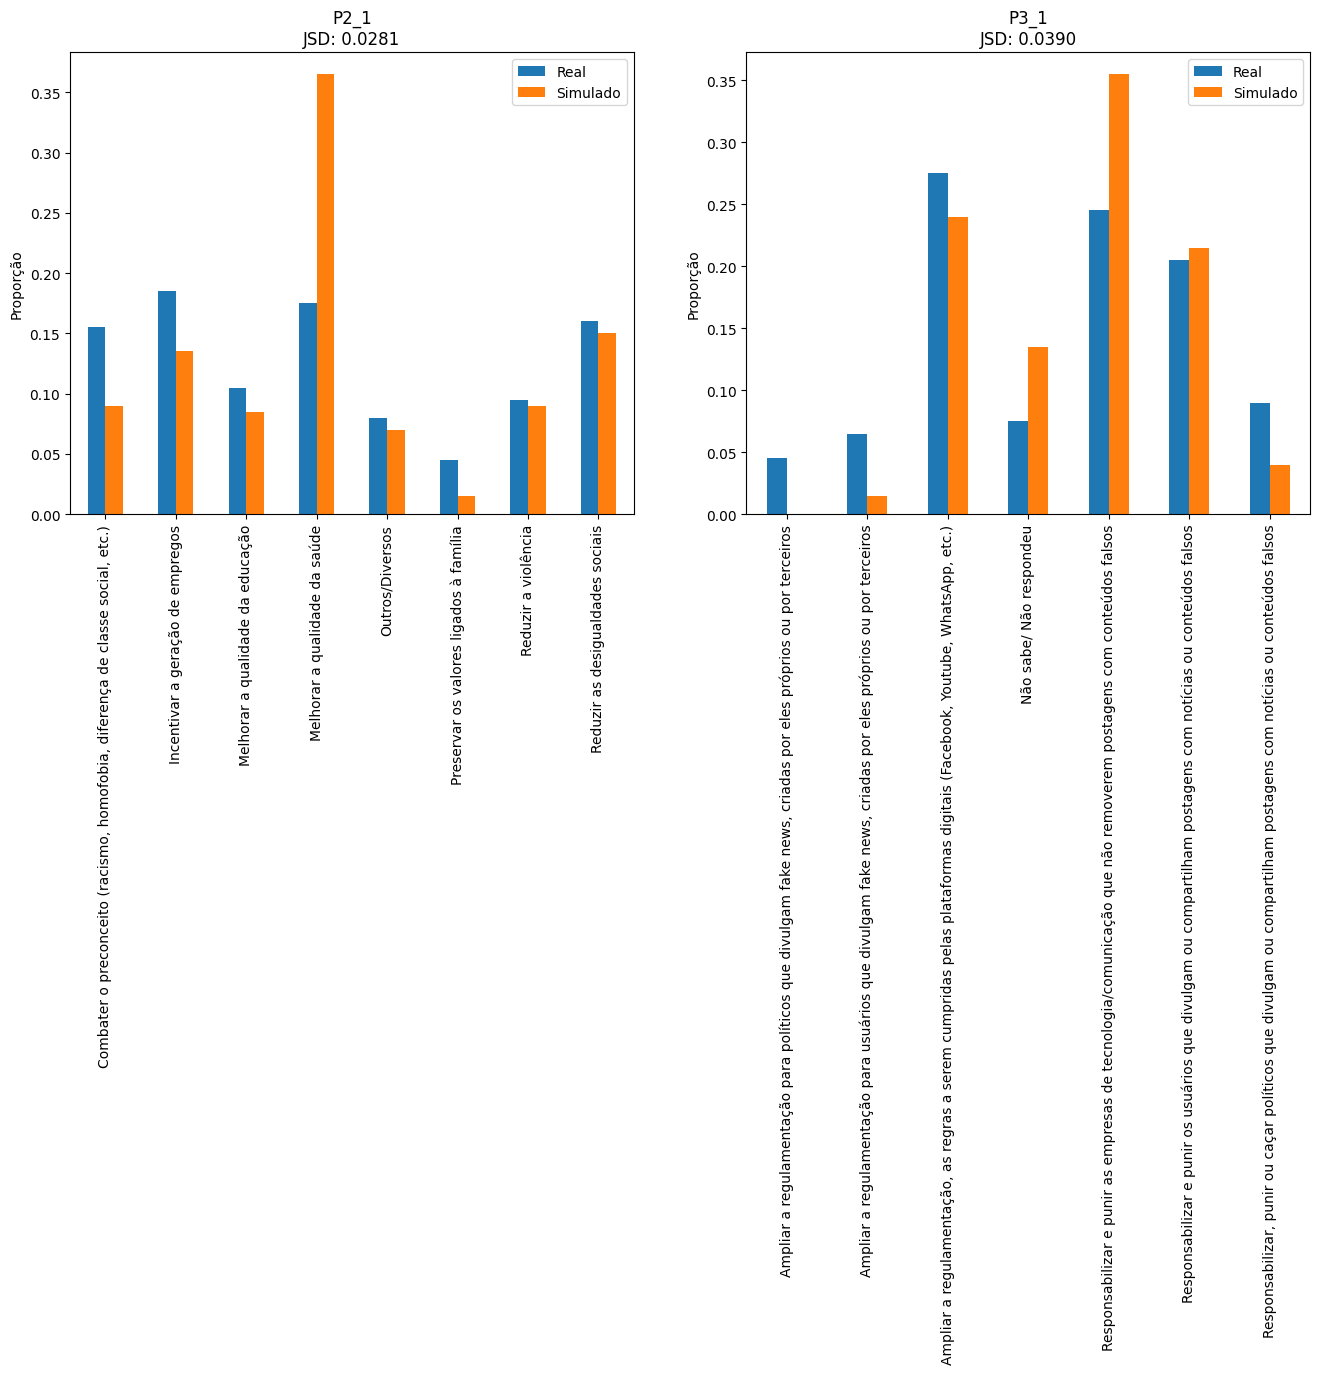

In [17]:
print("** Relatório de Métricas (F1-Score) **")

for i, col in enumerate(s_targets):
    print(f"\nTarget: {col}")
    print(
        classification_report(
            y_test_enc[:, i],  # Target esperado
            y_pred[:, i],  # Target classificado pelo modelo
            target_names=target_encoders[
                i
            ].classes_,  # Utiliza os labels de texto para melhor visualização
            zero_division=0,
        )
    )


def calculate_jsd(y_true, y_pred, n_classes):
    """
    Utilizamos o cálculo de Divergência de Jensen-Shannon (JSD) entre as distribuições
    (verdadeira e prevista) para identificar a distância entre cada classificação para
    avaliar a capacidade do modelo em simular a real distribuição estatística
    de uma pesquisa de opinião.

    A JSD é uma medida de similaridade entre duas distribuições de probabilidade.
    Valores próximos de 0 indicam que as distribuições são muito semelhantes.

    > Método gerado utilizando o modelo Gemini 3.0 Flash dentro do Google Colab
    """
    # np.histogram calcula a frequência de cada classe e normaliza para obter a distribuição de probabilidade.
    # p: distribuição verdadeira.
    p = np.histogram(y_true, bins=range(n_classes + 1), density=True)[0]
    # q: distribuição prevista.
    q = np.histogram(y_pred, bins=range(n_classes + 1), density=True)[0]
    # jensenshannon calcula a raiz quadrada da JSD, então elevamos ao quadrado para obter a JSD.
    return jensenshannon(p, q) ** 2


# Plot dos gráficos das distribuição P2_1 e P3_1 com JSD
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, col in enumerate(s_targets):
    n_cls = len(target_encoders[i].classes_)
    jsd_val = calculate_jsd(y_test_enc[:, i], y_pred[:, i], n_cls)

    # Calcula a distribuição de frequência das classes verdadeiras e previstas.
    true_dist = pd.Series(y_test_enc[:, i]).value_counts(normalize=True).sort_index()
    pred_dist = pd.Series(y_pred[:, i]).value_counts(normalize=True).sort_index()

    # Cria um DataFrame para facilitar a plotagem comparativa.
    df_dist = pd.DataFrame({"Real": true_dist, "Simulado": pred_dist}).fillna(0)
    # Mapeia os índices numéricos de volta para os nomes das classes para o eixo X.
    df_dist.index = target_encoders[i].classes_

    # Plota o gráfico de barras comparando as distribuições real e simulada.
    df_dist.plot(kind="bar", ax=axes[i], title=f"{col}\nJSD: {jsd_val:.4f}")
    axes[i].set_ylabel("Proporção")

# Ajusta automaticamente os parâmetros do subplot e exibe os gráficos
plt.tight_layout()
plt.show()